## Section RNN - Autoregressive Linear Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as  np
import matplotlib.pyplot as plt

## create datasest

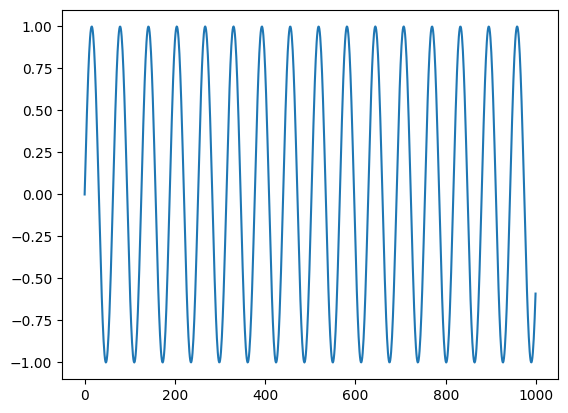

In [2]:
N = 1000

series = np.sin(0.1*np.arange(N)) # np.random.randn(N)*0.1
plt.plot(series)
plt.show()

In [3]:
#define dataset stuff

T = 10
D = 1
S = 1
# N = floor((L-T)/s)+1 => S(N-1)+T = L

X,y = [],[]

for t in range(N-T):
    X.append(series[t:t+T])
    y.append(series[t+T])

X = np.array(X).reshape(-1,T)
y = np.array(y).reshape(-1,1)
print(X.shape)
print(y.shape)
N = X.shape[0]

(990, 10)
(990, 1)


## define model

In [4]:
model = nn.Linear(T,1)
criterion = nn.MSELoss()
optimizer = opt.Adam(model.parameters(),lr=0.1)

train test split to half of the dataset


In [5]:
X_train = torch.from_numpy(X[:N//2].astype(np.float32))
X_test = torch.from_numpy(X[N//2:].astype(np.float32))
y_train = torch.from_numpy(y[:N//2].astype(np.float32))
y_test = torch.from_numpy(y[N//2:].astype(np.float32))

## train it all

In [6]:
epochs = 200
train_losses = []
test_losses = []
for epoch in range(epochs):
  
    optimizer.zero_grad()

    y_hat = model(X_train)

    loss = criterion(y_hat,y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(criterion(y_hat,y_train).item())
    y_tst_hat = model(X_test)
    test_losses.append(criterion(y_tst_hat,y_test).item())
    print(f"train loss {train_losses[-1]} test loss: {test_losses[-1]}")

train loss 0.9401935338973999 test loss: 0.14170466363430023
train loss 0.14049966633319855 test loss: 0.16812996566295624
train loss 0.17085795104503632 test loss: 0.40683242678642273
train loss 0.4154663681983948 test loss: 0.39434388279914856
train loss 0.40298905968666077 test loss: 0.21626953780651093
train loss 0.22106227278709412 test loss: 0.060353703796863556
train loss 0.06137321889400482 test loss: 0.027114052325487137
train loss 0.026638919487595558 test loss: 0.09581940621137619
train loss 0.09600809216499329 test loss: 0.16872304677963257
train loss 0.1700623780488968 test loss: 0.17294606566429138
train loss 0.17457367479801178 test loss: 0.11263077706098557
train loss 0.11363571882247925 test loss: 0.03931189700961113
train loss 0.03953269496560097 test loss: 0.0021146810613572598
train loss 0.0020747650414705276 test loss: 0.015518272295594215
train loss 0.015838811174035072 test loss: 0.05528603121638298
train loss 0.05613462254405022 test loss: 0.08268766850233078
tr

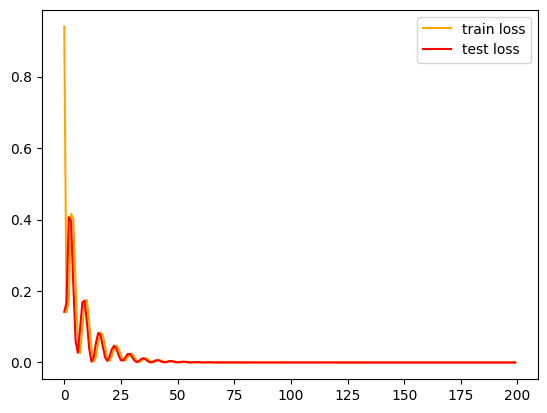

In [7]:
ticks = [x for x in range(len(train_losses))]

plt.plot(ticks,train_losses,label='train loss',color='orange')
plt.plot(ticks,test_losses,label='test loss',color='red')
plt.legend()

<span ><h1 style="color:red"><b>Now let's forecast THE WRONG WAY</b></h1></span>

In [8]:
validation_targets = y[N//2:]
validation_predictions = []
val_idx = 0

while len(validation_predictions) < len(validation_targets):
    inputs = X_test[val_idx].view(1,-1)
    pred = model(inputs)
    validation_predictions.append(pred[0,0].item())
    val_idx += 1


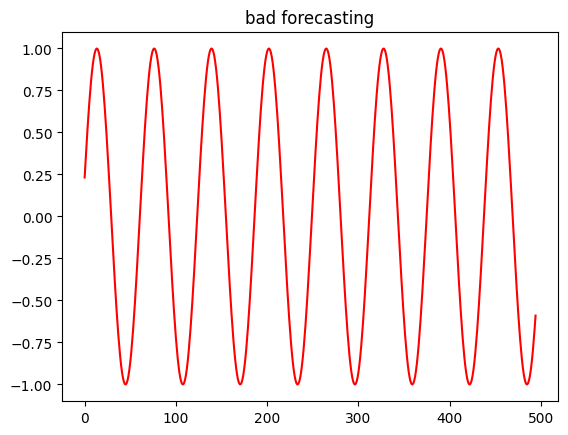

In [9]:
plt.title('bad forecasting')
plt.plot(validation_predictions,color='red')

again we took from test T samples a predicted the next then we again took T samples from test and predicted the next <b style="color:red">without considering the previous predictions</b>

<h1><b>Now let's forecast THE RIGHT WAY</b></h1>

In [10]:
val_idx = 0 
validation_targets = y[-N//2:]
validation_predictions = []
last_x = torch.from_numpy(X[-N//2].astype(np.float32))

In [11]:
while len(validation_predictions) < len(validation_targets) :
    inputs = last_x.view(1,-1)
    pred = model(inputs)
    validation_predictions.append(pred[0,0].item())
    val_idx += 1
    last_x = torch.cat((last_x[1:],pred[0]))
  

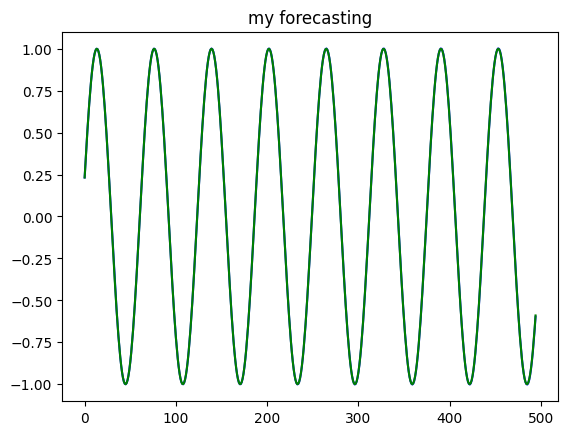

In [12]:
plt.title('my forecasting')
plt.plot(validation_predictions,color='blue')
plt.plot(validation_targets,color='green')